## Time series decomposition

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from matplotlib import rcParams
import matplotlib.pyplot as plt
import seaborn as sns
import holoviews as hv
import hvplot.pandas
import datetime as dt

In [2]:
import os
path = 'c:/Users/luisa/Desktop/thesis_project/code/deep_models/'
os.chdir(path)
from utils import build_df_sparse

In [40]:
df = pd.read_parquet('c:/Users/luisa/Desktop/thesis_project/data/tripsv3_cleaned.parquet')
df = df.sort_values(by=['trip_start']).reset_index(drop=True)

In [41]:
days = {0:'Monday', 1:'Tuesday', 2:'Wednesday', 3:'Thursday', 4:'Friday', 5:'Saturday', 6:'Sunday'}
df['weekday'] = [days[df.at[i, 'trip_start'].weekday()] for i in range(len(df))]
df['date'] = pd.to_datetime(df['trip_start']).dt.date

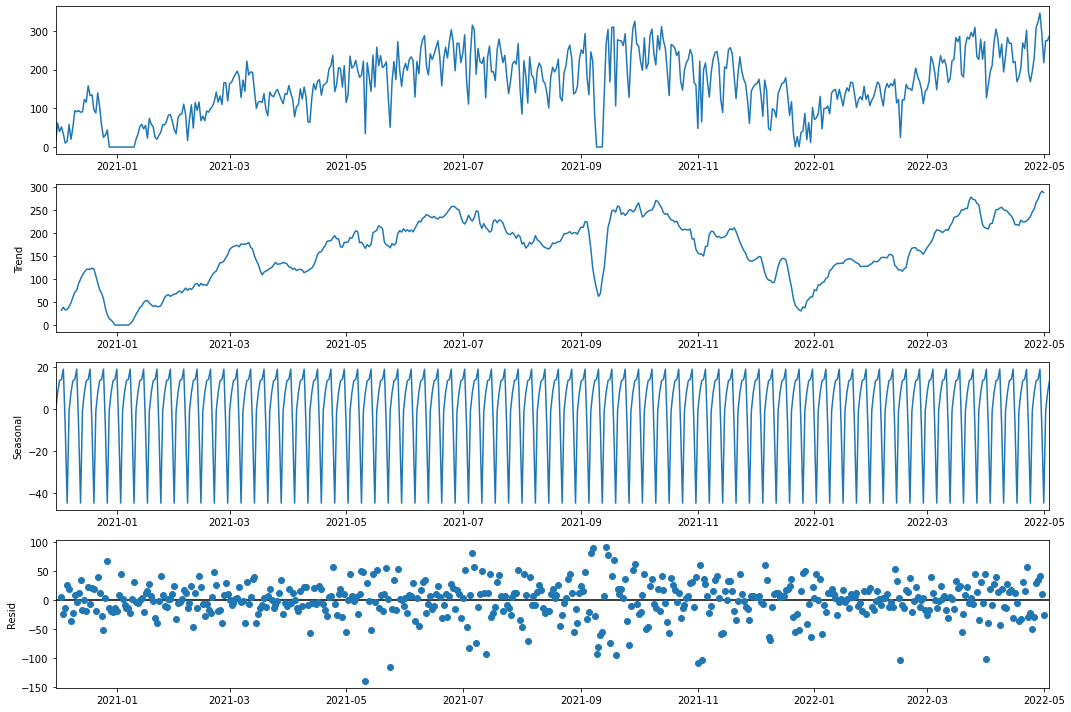

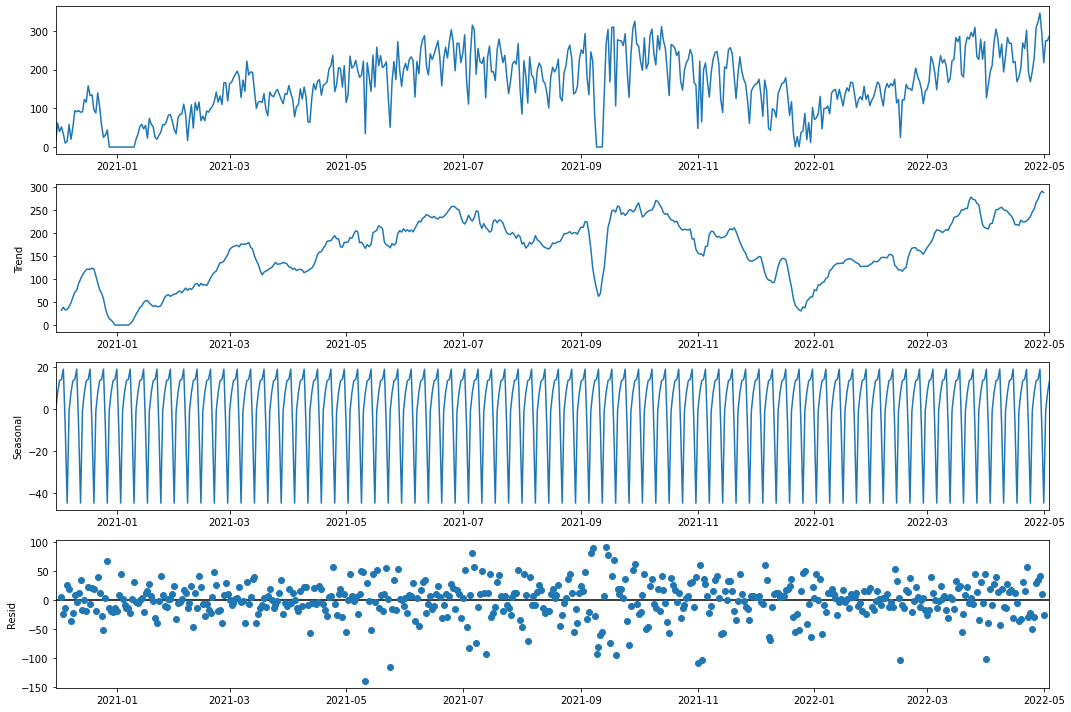

In [42]:
seasonality_data = df.copy(deep=True)
seasonality_data = seasonality_data[['date', 'unique_id']].groupby(['date']).agg(['count']).reset_index()
seasonality_data.columns = seasonality_data.columns.droplevel(1)
seasonality_data = seasonality_data.rename(columns={'unique_id':'cnt'})

# add missing dates
all_times = pd.DataFrame({'date': pd.date_range(df.date.min(), df.date.max(), freq='D')})
all_times['date'] = all_times['date'].dt.date
seasonality_data = pd.merge(all_times, seasonality_data, left_on='date', right_on='date', how='left').fillna(0)

# seasonal decomposition
rcParams["figure.figsize"] = 15, 10
dts = np.array(seasonality_data.date.min(), dtype=np.datetime64) + np.arange(len(seasonality_data.date.unique())) # from starting date, adding all days in dataset
cnt = np.array(seasonality_data.cnt)
seasonal_df = pd.DataFrame({'data': cnt}, index=dts)
sm.tsa.seasonal_decompose(seasonal_df, model='additive').plot()

#### Seasonality

Zoom-in into seasonal component:

<AxesSubplot:>

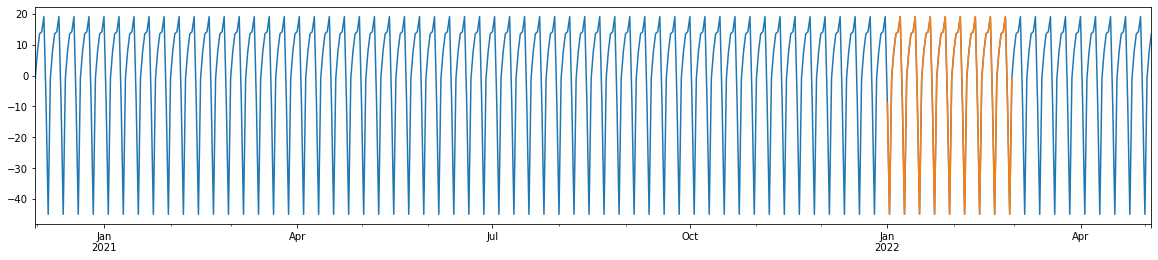

In [43]:
# seasonality
rcParams["figure.figsize"] = 20, 4
decomposition = sm.tsa.seasonal_decompose(seasonal_df, model='additive') # DecomposeResult object
decomposition.seasonal.plot()
decomposition.seasonal["2022-1":"2022-2"].plot() # highlight the area of zoom

<AxesSubplot:>

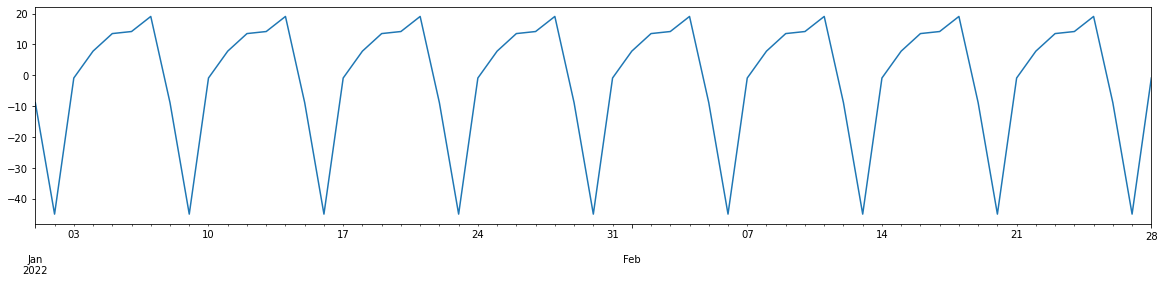

In [44]:
decomposition.seasonal["2022-1":"2022-2"].plot() # zoom-in into seasonality for better viz

#### Trend

<AxesSubplot:>

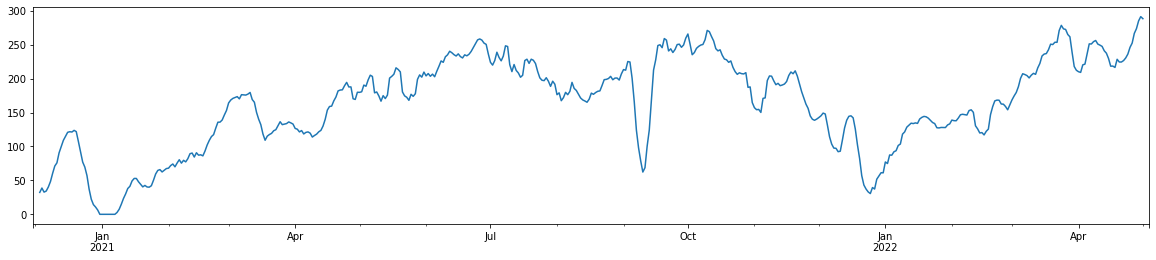

In [45]:
decomposition.trend.plot() # trend component

#### Residuals (noises)

<AxesSubplot:>

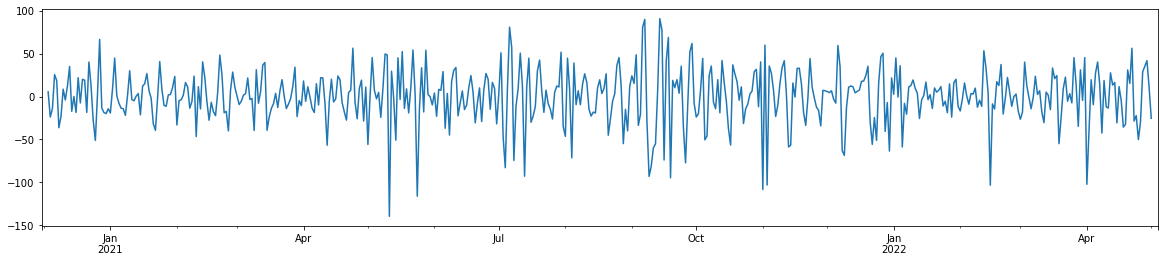

In [46]:
decomposition.resid.plot()

## Analysing timeseries for each cell in the grid

In [66]:
# SELECT PRECISION TO BE USED FOR ALL THE FOLLOWING ANALYSIS: 
# the precision is used to create a grid dividing the city into equally-sized blocks or cells,
# the greatest the precision, the lower the dimension of the blocks

# EXAMPLES:
# precision = 5 divides the city into 6 blocks with dimension <= 4.89km x 4.89km
# precision = 6 divides the city into 40 blocks with dimensions <= 1.22km x 0.61km

precision = 5

In [67]:
# create cells code
df = build_df_sparse(precision=precision, freq='H') # must use always same precision and freq to obtain always the same code for the cells
df = df.reset_index()
all_gh = df.gh.unique()
gh_to_int = {gh_id:i for i, gh_id in enumerate(all_gh)}
int_to_gh = {i:gh_id for i, gh_id in enumerate(all_gh)}

In [68]:
df = build_df_sparse(precision=precision, freq='D')
df

,trips_count,gh,totalSnow_cm,precipMM,tempC,visibility,windspeedKmph,month,hour,day_of_week,day_of_month,is_weekend,holiday
trip_start,,,,,,,,,,,,,
2020-11-30,13.0,"(46.07666015625, 11.14013671875)",0.0,0.000000,6.041667,10.000,1.583333,11,0,0,30,False,False
2020-11-30,0.0,"(46.12060546875, 11.09619140625)",0.0,0.000000,6.041667,10.000,1.583333,11,0,0,30,False,False
2020-11-30,0.0,"(46.03271484375, 11.14013671875)",0.0,0.000000,6.041667,10.000,1.583333,11,0,0,30,False,False
2020-11-30,0.0,"(46.03271484375, 11.09619140625)",0.0,0.000000,6.041667,10.000,1.583333,11,0,0,30,False,False
2020-11-30,0.0,"(46.07666015625, 11.09619140625)",0.0,0.000000,6.041667,10.000,1.583333,11,0,0,30,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-05-04,31.0,"(46.03271484375, 11.14013671875)",0.0,0.045833,9.416667,9.875,4.333333,5,0,2,4,False,False
2022-05-04,62.0,"(46.07666015625, 11.09619140625)",0.0,0.045833,9.416667,9.875,4.333333,5,0,2,4,False,False
2022-05-04,191.0,"(46.07666015625, 11.14013671875)",0.0,0.045833,9.416667,9.875,4.333333,5,0,2,4,False,False


In [50]:
# replace centroids with the above defined cells codes 
df = df.reset_index()
df['gh'] = [gh_to_int[df.at[i, 'gh']] for i in range(len(df))]
df.set_index('trip_start', inplace=True)

Text(0, 0.5, 'number of trips')

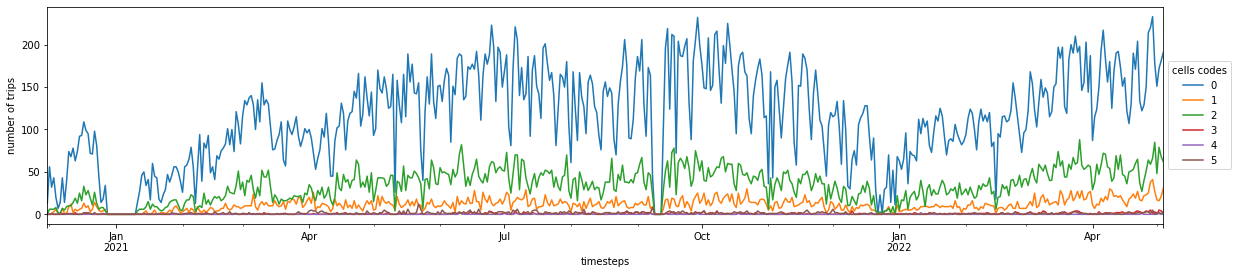

In [29]:
df[['trips_count', 'gh']].groupby('gh')['trips_count'].plot()
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), title='cells codes', ncol=1)
plt.xlabel('timesteps')
plt.ylabel('number of trips')

Text(0, 0.5, 'number of trips')

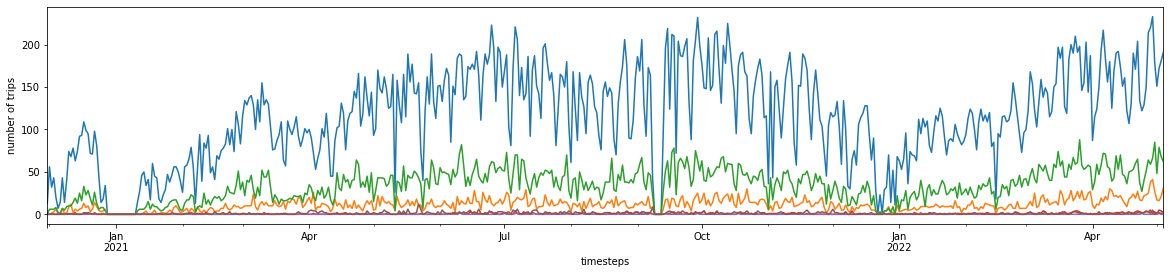

In [30]:
df[['trips_count', 'gh']].groupby('gh')['trips_count'].plot(legend=False)
plt.xlabel('timesteps')
plt.ylabel('number of trips')

Text(0, 0.5, 'number of trips')

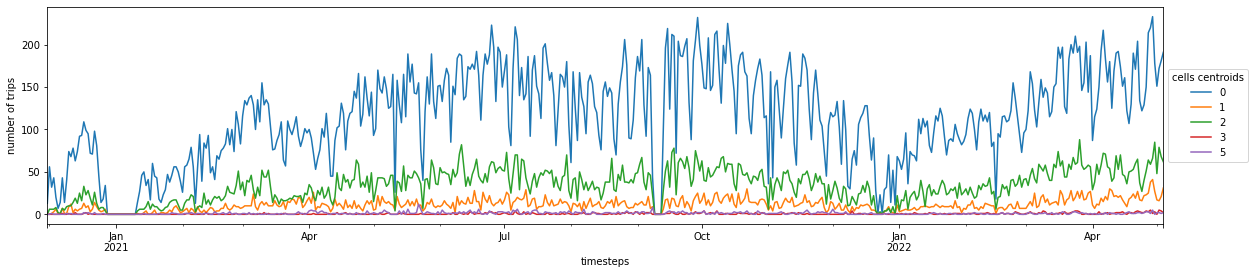

In [31]:
# take top-5 cells for number of trips
top_cells = df[['trips_count', 'gh']].groupby('gh').aggregate({'trips_count':'sum'}).sort_values(by='trips_count', ascending=False).reset_index()[:5].gh.to_list()
# take only rows concerning these top10 cells
top_df = df.loc[df.apply(lambda x: x.gh in top_cells, axis=1)]
# plot trend of these cells
top_df[['trips_count', 'gh']].groupby('gh')['trips_count'].plot()
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), title='cells centroids', ncol=1)
plt.xlabel('timesteps')
plt.ylabel('number of trips')

In [69]:
from GNN_LSTM_data_prep import prepare_data
data, _, _, _, _ = prepare_data(precision=precision, freq='H') # same freq for same cells' code

In [70]:
data = data.reset_index()
data = data.rename(columns={'row_0':'date'})
data['date'] = data.date.dt.date
data = data.groupby(['date']).sum()
data

gh,0,1,2,3,4,5
date,,,,,,
2020-11-30,13.0,0.0,0.0,0.0,0.0,0.0
2020-12-01,56.0,0.0,6.0,0.0,0.0,0.0
2020-12-02,32.0,1.0,6.0,0.0,0.0,1.0
2020-12-03,43.0,3.0,6.0,0.0,0.0,0.0
2020-12-04,20.0,6.0,8.0,0.0,0.0,0.0
...,...,...,...,...,...,...
2022-04-30,178.0,27.0,85.0,3.0,0.0,0.0
2022-05-01,151.0,17.0,48.0,0.0,0.0,2.0
2022-05-02,172.0,16.0,79.0,5.0,1.0,2.0


In [71]:
# put index type as pd.DatetimeIndex for timeseries decomp.
data = data.reset_index()
data = data.set_index(pd.DatetimeIndex(data['date']))
del data['date']

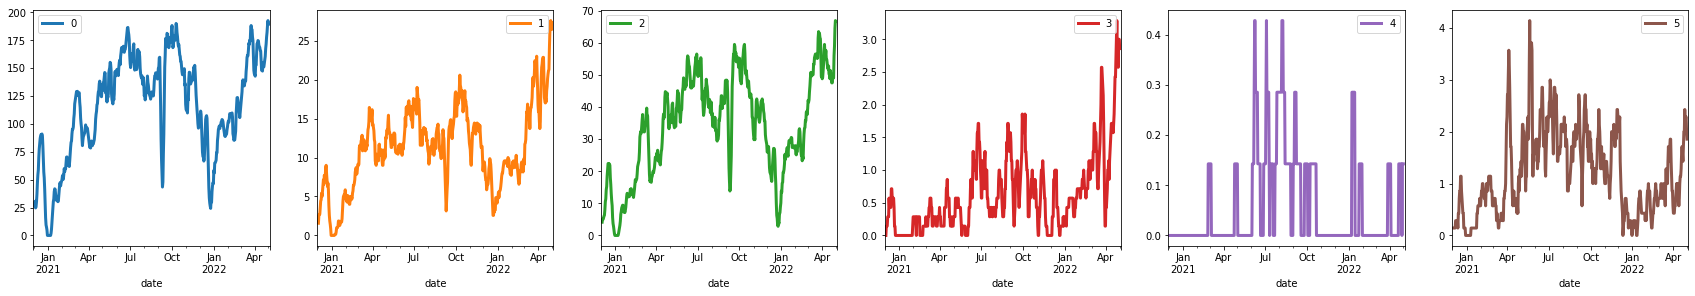

In [72]:
# initialize empty dict to store decompose results
trend_diz = {}

for ts in data.columns:
    decompositions = sm.tsa.seasonal_decompose(data[ts])
    # store results in the dictionary
    trend_diz[ts] = decompositions.trend

# TREND BY CELL
rcParams["figure.figsize"] = 50, 20
pd.DataFrame(trend_diz).plot(subplots=True, layout=(4, 10), linewidth=3);

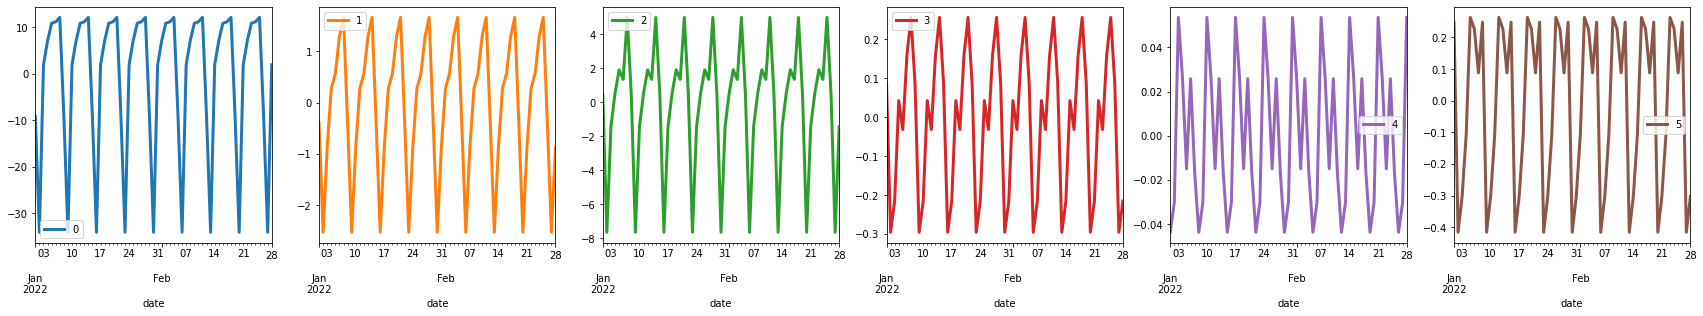

In [21]:
seasonality_diz = {}

for ts in data.columns:
    decompositions = sm.tsa.seasonal_decompose(data[ts])
    # store results in the dictionary
    seasonality_diz[ts] = decompositions.seasonal

# SEASONALITY BY CELL
rcParams["figure.figsize"] = 50, 20
# pd.DataFrame(seasonality_diz).plot(subplots=True, layout=(10, 4), linewidth=3);
pd.DataFrame(seasonality_diz)["2022-1":"2022-2"].plot(subplots=True, layout=(4, 10), linewidth=3); # zoom-in for better viz

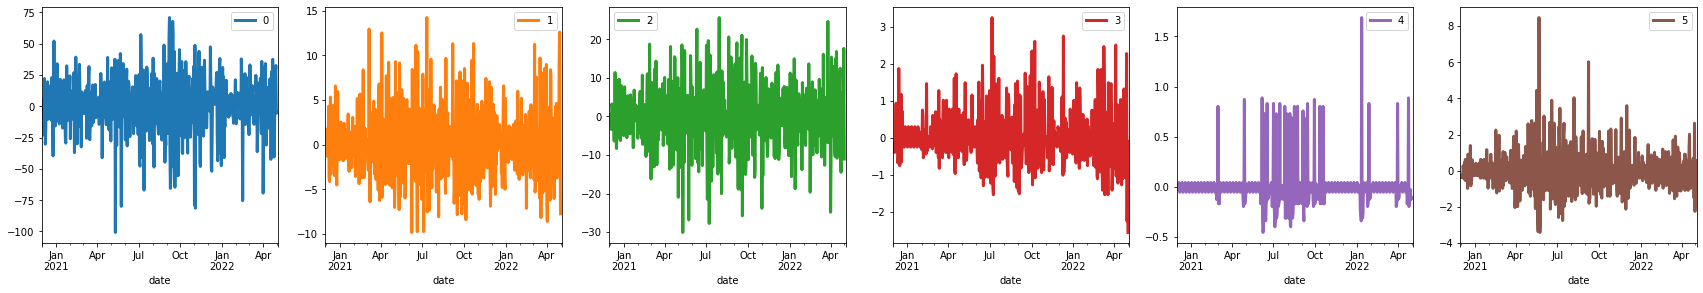

In [22]:
resid_diz = {}

for ts in data.columns:
    decompositions = sm.tsa.seasonal_decompose(data[ts])
    resid_diz[ts] = decompositions.resid

# RESIDUALS BY CELL
rcParams["figure.figsize"] = 50, 20
pd.DataFrame(resid_diz).plot(subplots=True, layout=(4, 10), linewidth=3);

### Correlation of trips in one cell with trips on the others

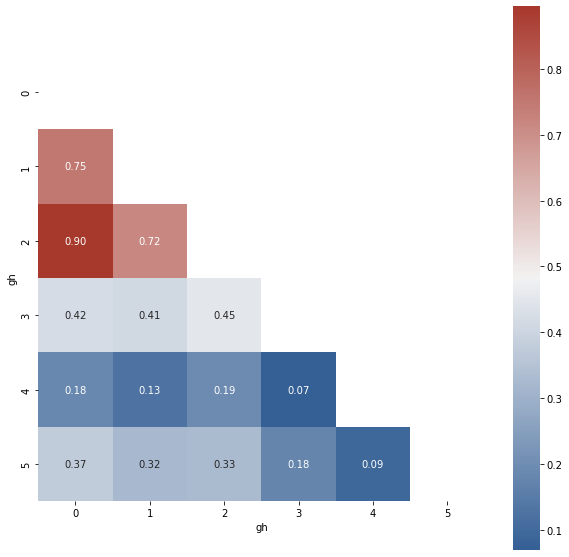

In [73]:
# palette
cmap = sns.diverging_palette(250, 15, s=75, l=40, n=9, center="light", as_cmap=True)

# correlation matrix
matrix = data.corr(method="pearson")
# mask
mask = np.triu(np.ones_like(matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(matrix, mask=mask, cmap=cmap, square=True, annot=True, fmt=".2f", ax=ax)
plt.show();

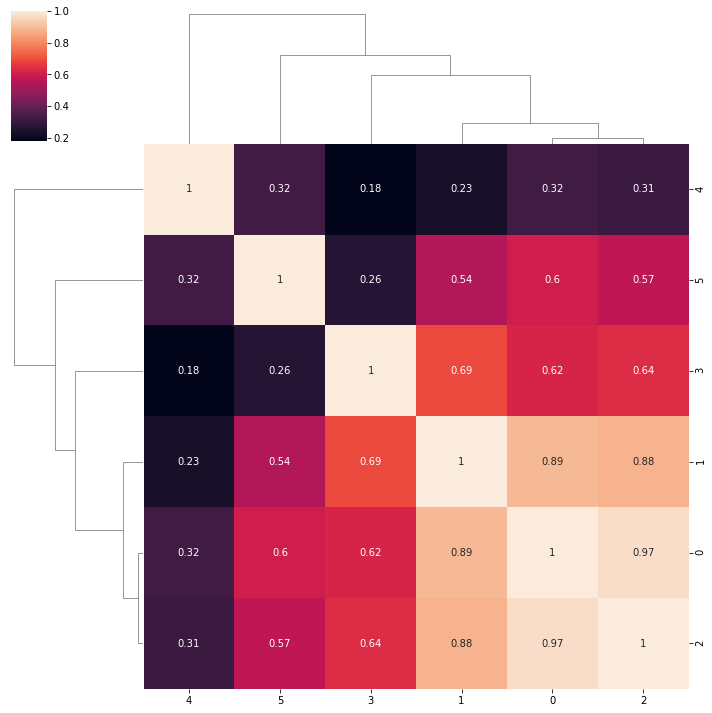

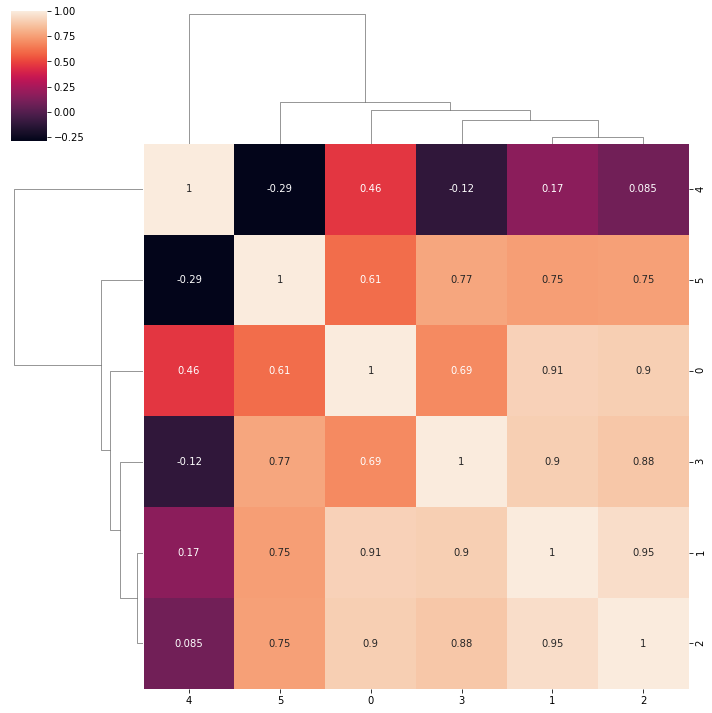

In [24]:
# check how underlying components of time series affect each other:

# 1. how TREND of each time series influences others: 
# lighter colors shows that the trends of the correspinding cells are highly (positively) correlated,
# while darker colors define negative correlation between trends.
# positive correlation can be indicative of close trend matches -> increasing trips in one cell, will increase also in the other
trend_dict = { ts: sm.tsa.seasonal_decompose(data[ts]).trend for ts in data.columns }

trend_dict = pd.DataFrame(trend_dict).corr() # corr matrix

sns.clustermap(trend_dict, annot=True, square=True)
plt.show();

# 2. how SEASONALITY of each time series influences others:
# positive correlation can be indicative of close seasonality matches -> similar cyclic pattern between the two cells, that follows closely one another when altered
seasonality_dict = { ts: sm.tsa.seasonal_decompose(data[ts]).seasonal for ts in data.columns }

seasonality_corr = pd.DataFrame(seasonality_dict).corr() 

rcParams["figure.figsize"] = 50, 50
sns.clustermap(seasonality_corr, annot=True, square=True) 
plt.show();

#### Remove cells (3, 4, 5) with zero-trends and increment spatial divisions of others

In [29]:
gh_to_int

{'(46.07666015625, 11.14013671875)': 0,
 '(46.03271484375, 11.14013671875)': 1,
 '(46.07666015625, 11.09619140625)': 2,
 '(46.12060546875, 11.09619140625)': 3,
 '(46.12060546875, 11.14013671875)': 4,
 '(46.03271484375, 11.09619140625)': 5}

In [30]:
from utils import addToGeohash, getGeohash

# centroids of cells with null-trend
centroids=[(46.12060546875, 11.09619140625),
(46.12060546875, 11.14013671875),
(46.03271484375, 11.09619140625)]
m = dict()

gh_null_trends = []

for pt in range(len(centroids)):
    addToGeohash(m, centroids[pt][0], centroids[pt][1], 5) 
    gh_null_trends.append(getGeohash(m, centroids[pt][0], centroids[pt][1], 5))

gh_null_trends

['u0pyk', 'u0pym', 'u0pvu']

In [35]:
df = pd.read_parquet('C:/Users/luisa/Desktop/thesis_project/data/tripsv3_augmented.parquet')

In [38]:
df['gh_prec5'] = [df.at[i, 'geohash_origin'][:-1] for i in range(len(df))]

In [41]:
df = df[~df['gh_prec5'].isin(gh_null_trends)]

In [74]:
# from GNN_LSTM_data_prep import prepare_data
data, _, _, _, _ = prepare_data(precision=6, freq='H') 
data = data.reset_index()
data = data.rename(columns={'row_0':'date'})
data['date'] = data.date.dt.date
data = data.groupby(['date']).sum()
# put index type as pd.DatetimeIndex for timeseries decomp.
data = data.reset_index()
data = data.set_index(pd.DatetimeIndex(data['date']))
del data['date']

In [112]:
best_cells=[]
for col in data.columns:
    if data[col].max()>10:
        best_cells.append(col)

In [113]:
best_cells = [0, 3, 11, 14, 16, 17, 26, 35, 37, 8, 24, 28]

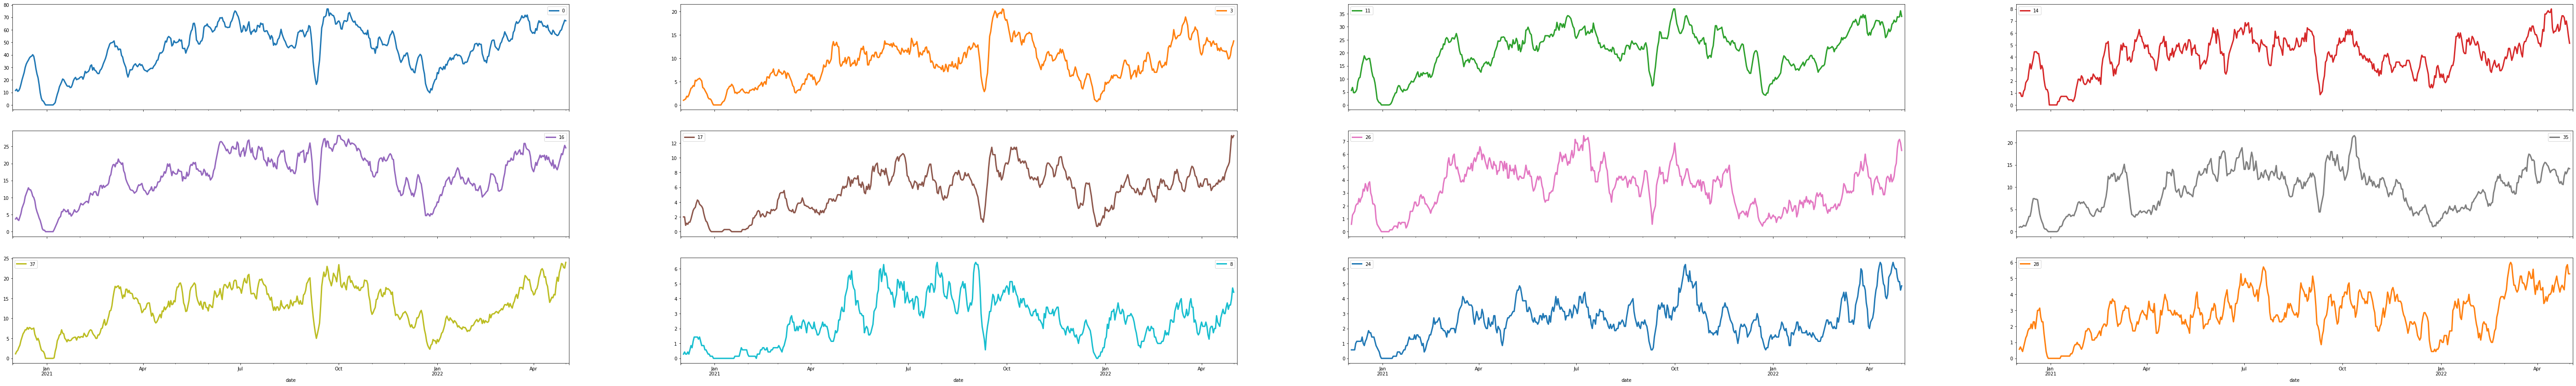

In [121]:
# initialize empty dict to store decompose results
trend_diz = {}

for ts in best_cells: # select cells with greatest trends
    decompositions = sm.tsa.seasonal_decompose(data[ts])
    # store results in the dictionary
    trend_diz[ts] = decompositions.trend

# TREND BY CELL
rcParams["figure.figsize"] = 100, 50
pd.DataFrame(trend_diz).plot(subplots=True, layout=(10, 4), linewidth=3);

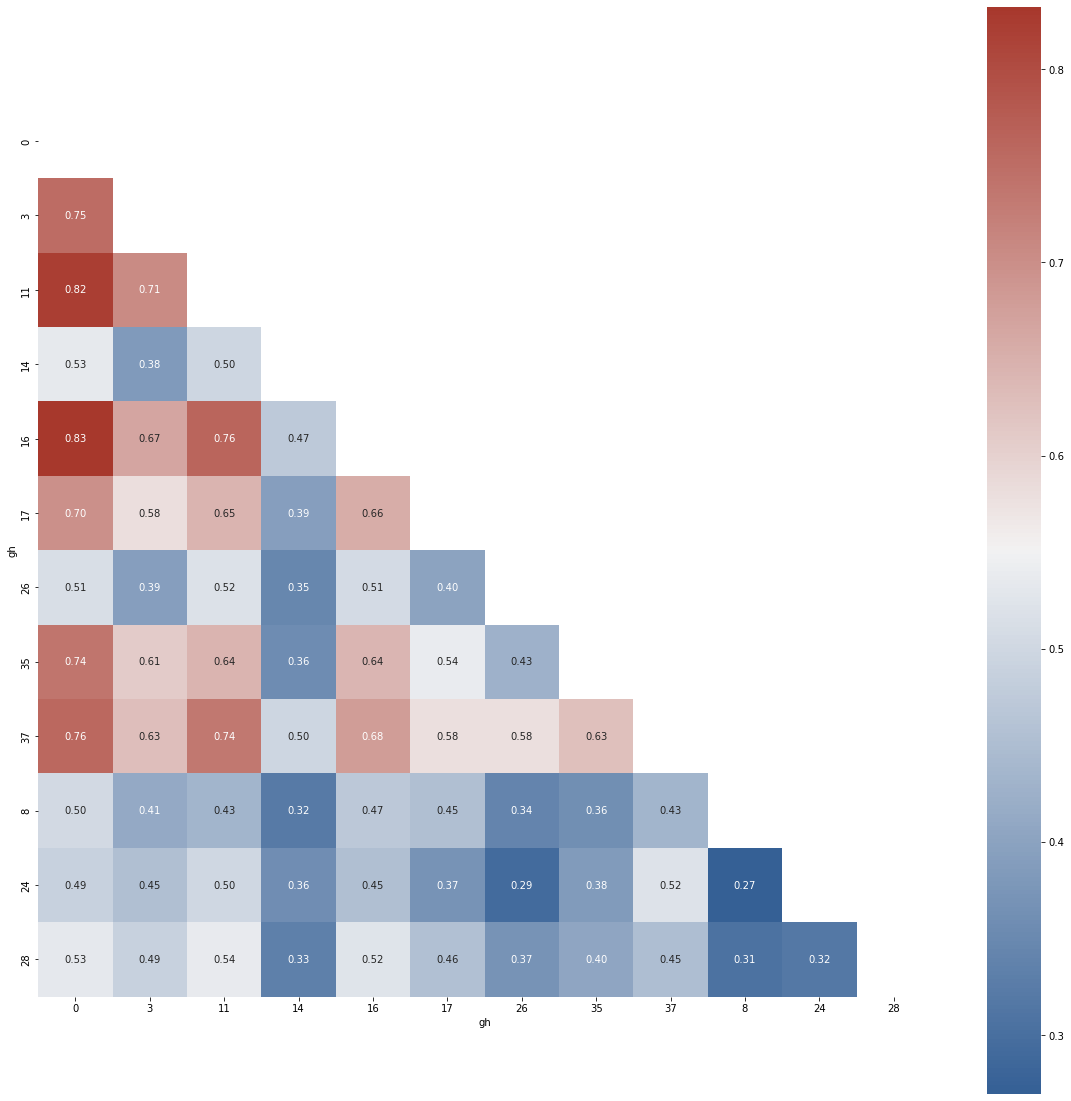

In [115]:
# CORRELATION HEATMAP FOR THE BEST CELLS

cmap = sns.diverging_palette(250, 15, s=75, l=40, n=9, center="light", as_cmap=True)

# correlation matrix
matrix = data[best_cells].corr(method="pearson")
# mask
mask = np.triu(np.ones_like(matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(matrix, mask=mask, cmap=cmap, square=True, annot=True, fmt=".2f", ax=ax)
plt.show();

### Covid-19 impact
#### Covid-19: storico contagi, ricoveri e decessi in Trentino
Secondo quanto riscontrabile al seguente [link](https://covid19trentino.fbk.eu/), in Trentino (e in particolar modo nell'area di Trento), i periodi di maggior intensità dell'emergenza sanitaria sono i seguenti:
- **massimo numero di contagi al giorno**: periodo `29/12/2021 - 08/02/2022`, con picchi più elevati in corrispondenza del 14/01/2022 e del 24/01/2022
- **periodi ad alto tasso di ricoveri**: periodo `11/03/2020 - 26/5/2020`, con picchi il 30/3/2020 e l' 8/4/2020, periodo `17/10/2020 - 1/05/2021`, con picchi il 23/11/2020, 9/12/2020, 3/1/2021 e 29/3/2021, e infine, anche se di entità decisamente inferiore, periodo `26/11/2021 - 13/3/2022`, con lieve picco intorno al 5/2/2022
- **periodo ad alto tasso di decessi**:` 20/3/2020 - 1/5/2020`, con picco intorno al 31/3/2020 e periodo `1/11/2020 - 2/2/2021`, con picco intorno al 18/12/2020

Inoltre, i periodi di lockdown e le fasi dell'emergenza sanitaria a livello nazionale sono:
- **lockdown**: 9/03/2020 - 18/05/2020
- **allentamento misure di contenimento**: 4/05/2020 - 14/06/2020
- convivenza con il covid: 15/06/2020 - 7/10/2020
- **nuove misure restrittive**: 8/10/2020 - 5/11/2020
- **coprifuoco** dalle ore 22.00 alle 5.00 del mattino e istituzione zone gialle, arancioni, rosse: dal 6/11/2020
- **misure restrittive periodo natalizio**: 21/12/2020 - 15/01/2021
- istituzione zone bianche: dal 16/1/2021
- inasprimento misure contenimento: 6/03/2021 - 25/04/2021
- **obbligo di certificazione verde**: dal 6/08/2021
- fine stato di emergenza: 1/04/2022

(Dati estratti da [wikipedia](https://it.wikipedia.org/wiki/Gestione_della_pandemia_di_COVID-19_in_Italia#Nuove_restrizioni_e_green_pass_vaccinale_(6_dicembre_2021_-_31_marzo_2022)) in data 16/06/2022)

In [3]:
df = pd.read_parquet('c:/Users/luisa/Desktop/thesis_project/data/tripsv3_cleaned.parquet')
df = df.sort_values(by=['trip_start']).reset_index(drop=True)
df['date'] = pd.to_datetime(df['trip_start']).dt.date

# add missing dates
all_times = pd.DataFrame({'date': pd.date_range(df.date.min(), df.date.max(), freq='D')})
all_times['date'] = all_times['date'].dt.date
df = pd.merge(all_times, df, left_on='date', right_on='date', how='left').fillna(0)


In [4]:
def aggregate_df(df):
    df = df.groupby(['date']).agg({'date':['count']})
    df.columns = df.columns.droplevel([1])
    df.rename(columns = {'date':'num_trips'}, inplace = True)
    return df.reset_index()

def escooter_contagi(data_inizio_periodo, data_fine_periodo, y, label, picchi, plot_title):
    # periods
    before = df[df.date<=data_inizio_periodo]
    picco_contagi = df.loc[(df.date>data_inizio_periodo)&(df.date<=data_fine_periodo)]
    after = df[(df.date>data_fine_periodo)]
    # aggregate
    before = aggregate_df(before)
    picco_contagi = aggregate_df(picco_contagi)
    after = aggregate_df(after)
    # compute average
    avg_before = before[y].sum() / len(before)
    avg_picco = picco_contagi[y].sum() / len(picco_contagi)
    avg_after = after[y].sum() / len(after)
    event = [avg_before, avg_picco, avg_after]
    avg_data = dict(
        start=[before.date.min(), data_inizio_periodo, data_fine_periodo],
        end=[data_inizio_periodo, data_fine_periodo, after.date.max()],   
        start_event = event,
        end_event = event
    )
    max_cont_plt = before.hvplot(x='date', y=y, label='Pre-peak situation').opts(width=1000, height=400)
    max_cont_plt = max_cont_plt * picco_contagi.hvplot(x='date', y=y, label='Maximum hospitalization')
    max_cont_plt = max_cont_plt * after.hvplot(x='date', y=y, label='Decrease in infections')
    max_cont_plt = max_cont_plt * hv.Segments(avg_data, [hv.Dimension('start'), hv.Dimension('start_event'), 'end', 'end_event'], label=label).opts(color='gray', line_dash='dashed')
    max_cont_plt = max_cont_plt * hv.VLine(data_inizio_periodo).opts(color='gray', line_width=1.5, line_dash='dashed')
    max_cont_plt = max_cont_plt * hv.VLine(data_fine_periodo).opts(color='gray', line_width=1.5, line_dash='dashed')
    max_cont_plt = max_cont_plt * hv.Spikes((picchi, [avg_picco]*len(picchi)), vdims='height', label='Infection peaks').opts(color='darkred', line_width=2.0)
    return max_cont_plt.relabel(plot_title).opts(legend_position='top_left')



# peaks infections: 14/01/2022 and 24/01/2022
# max hospitalization in the considered period of e-scooters data: from 26/11/2021 to 13/3/2022
escooter_contagi(dt.date(2021, 11, 26), dt.date(2022, 3, 13), 'num_trips', 'Average number of trips', [dt.date(2022, 1, 14), dt.date(2022, 1, 24)], "Covid-19 hospitalization and e-scooters rates")


:Overlay
   .Curve.Pre_hyphen_minus_peak_situation :Curve   [date]   (num_trips)
   .Curve.Maximum_hospitalization         :Curve   [date]   (num_trips)
   .Curve.Decrease_in_infections          :Curve   [date]   (num_trips)
   .Segments.Average_number_of_trips      :Segments   [start,start_event,end,end_event]
   .VLine.I                               :VLine   [x,y]
   .VLine.II                              :VLine   [x,y]
   .Spikes.Infection_peaks                :Spikes   [x]   (height)